In [1]:
# Load UNSW-NB15 Dataset 
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

UNSW_PATH   = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data\UNSW-NB15"
DATA_PATH   = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data"
MODEL_PATH  = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\models"
RESULT_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\results"

# Load saved artifacts from CICIDS2017 training
rf            = joblib.load(f"{MODEL_PATH}\\random_forest.pkl")
le_cicids     = joblib.load(f"{DATA_PATH}\\label_encoder.pkl")
feature_names = joblib.load(f"{DATA_PATH}\\feature_names.pkl")
scaler        = joblib.load(f"{DATA_PATH}\\scaler.pkl")

print("Loading UNSW-NB15 CSV files...")
dfs = []
for i in range(1, 5):
    path = f"{UNSW_PATH}\\UNSW-NB15_{i}.csv"
    df_temp = pd.read_csv(path, header=None,
                          low_memory=False,
                          encoding='latin-1')
    dfs.append(df_temp)
    print(f"  Loaded UNSW-NB15_{i}.csv — {len(df_temp):,} rows")

df_unsw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined: {df_unsw.shape[0]:,} rows x {df_unsw.shape[1]} columns")

# Load feature names from UNSW features file
feat_path = f"{UNSW_PATH}\\UNSW-NB15_features.csv"
features_df = pd.read_csv(feat_path, encoding='latin-1')
print(f"\nFeature file loaded: {len(features_df)} features defined")
print(f"Feature file columns: {list(features_df.columns)}")
print(f"\nFirst 10 feature names:")
print(features_df.iloc[:10].to_string())

Loading UNSW-NB15 CSV files...
  Loaded UNSW-NB15_1.csv — 700,001 rows
  Loaded UNSW-NB15_2.csv — 700,001 rows
  Loaded UNSW-NB15_3.csv — 700,001 rows
  Loaded UNSW-NB15_4.csv — 440,044 rows

Combined: 2,540,047 rows x 49 columns

Feature file loaded: 49 features defined
Feature file columns: ['No.', 'Name', 'Type ', 'Description']

First 10 feature names:
   No.    Name    Type                                                                                                                                                      Description
0    1   srcip  nominal                                                                                                                                               Source IP address
1    2   sport  integer                                                                                                                                              Source port number
2    3   dstip  nominal                                                                  

In [2]:
# Assign column names from features file
# The feature name column is usually the second column
col_names = features_df.iloc[:, 1].tolist()
print(f"Number of feature names: {len(col_names)}")
print(f"Number of dataset columns: {df_unsw.shape[1]}")

# Assign column names
if len(col_names) == df_unsw.shape[1]:
    df_unsw.columns = col_names
    print("Column names assigned successfully")
else:
    # Use numeric columns and assign what we can
    print(f"Column count mismatch — assigning available names")
    df_unsw.columns = [str(i) for i in range(df_unsw.shape[1])]

print(f"\nColumn names:")
for i, col in enumerate(df_unsw.columns):
    print(f"  {i:2d}: {col}")

Number of feature names: 49
Number of dataset columns: 49
Column names assigned successfully

Column names:
   0: srcip
   1: sport
   2: dstip
   3: dsport
   4: proto
   5: state
   6: dur
   7: sbytes
   8: dbytes
   9: sttl
  10: dttl
  11: sloss
  12: dloss
  13: service
  14: Sload
  15: Dload
  16: Spkts
  17: Dpkts
  18: swin
  19: dwin
  20: stcpb
  21: dtcpb
  22: smeansz
  23: dmeansz
  24: trans_depth
  25: res_bdy_len
  26: Sjit
  27: Djit
  28: Stime
  29: Ltime
  30: Sintpkt
  31: Dintpkt
  32: tcprtt
  33: synack
  34: ackdat
  35: is_sm_ips_ports
  36: ct_state_ttl
  37: ct_flw_http_mthd
  38: is_ftp_login
  39: ct_ftp_cmd
  40: ct_srv_src
  41: ct_srv_dst
  42: ct_dst_ltm
  43: ct_src_ ltm
  44: ct_src_dport_ltm
  45: ct_dst_sport_ltm
  46: ct_dst_src_ltm
  47: attack_cat
  48: Label


In [3]:
# Check last few columns
print("Last 5 columns sample:")
print(df_unsw.iloc[:5, -5:].to_string())

print(f"\nLast column name: {df_unsw.columns[-1]}")
print(f"Second to last  : {df_unsw.columns[-2]}")

# Check value counts of last two columns
print(f"\nLast column value counts:")
print(df_unsw.iloc[:, -1].value_counts().head(20))

print(f"\nSecond to last column value counts:")
print(df_unsw.iloc[:, -2].value_counts().head(20))

Last 5 columns sample:
   ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm attack_cat  Label
0                 1                 1               1        NaN      0
1                 1                 1               2        NaN      0
2                 2                 1               1        NaN      0
3                 1                 1               1        NaN      0
4                 1                 1               1        NaN      0

Last column name: Label
Second to last  : attack_cat

Last column value counts:
Label
0    2218764
1     321283
Name: count, dtype: int64

Second to last column value counts:
attack_cat
Generic             215481
Exploits             44525
 Fuzzers             19195
DoS                  16353
 Reconnaissance      12228
 Fuzzers              5051
Analysis              2677
Backdoor              1795
Reconnaissance        1759
 Shellcode            1288
Backdoors              534
Shellcode              223
Worms                  174
Name: c

In [4]:
# Preprocess UNSW-NB15 for Binary Validation 
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Preprocessing UNSW-NB15 for binary validation...")

# Step 1: Use binary Label column 
# 0 = Benign, 1 = Attack
y_unsw_binary = df_unsw['Label'].values
print(f"\nBinary label distribution:")
print(f"  Benign (0): {(y_unsw_binary == 0).sum():,} ({(y_unsw_binary == 0).mean()*100:.1f}%)")
print(f"  Attack (1): {(y_unsw_binary == 1).sum():,} ({(y_unsw_binary == 1).mean()*100:.1f}%)")

# Step 2: Select numeric features only 
X_unsw_raw = df_unsw.select_dtypes(include=[np.number]).copy()

# Drop Label column from features
if 'Label' in X_unsw_raw.columns:
    X_unsw_raw = X_unsw_raw.drop(columns=['Label'])

print(f"\nNumeric features available in UNSW-NB15: {X_unsw_raw.shape[1]}")
print(f"Numeric features used in our model     : {len(feature_names)}")

# Step 3: Find common features 
unsw_cols_lower  = {col.lower().strip(): col for col in X_unsw_raw.columns}
cicids_cols_lower = {col.lower().strip(): col for col in feature_names}

common_lower = set(unsw_cols_lower.keys()) & set(cicids_cols_lower.keys())
print(f"\nExact matching features: {len(common_lower)}")
if common_lower:
    for c in sorted(common_lower):
        print(f"  {c}")

Preprocessing UNSW-NB15 for binary validation...

Binary label distribution:
  Benign (0): 2,218,764 (87.4%)
  Attack (1): 321,283 (12.6%)

Numeric features available in UNSW-NB15: 39
Numeric features used in our model     : 47

Exact matching features: 0


In [5]:
# Direct Binary Validation on UNSW-NB15 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler
import time

print("Preparing UNSW-NB15 for binary classification...")
print("="*60)

# Get numeric features only — drop Label
X_unsw_num = df_unsw.select_dtypes(include=[np.number]).copy()
if 'Label' in X_unsw_num.columns:
    X_unsw_num = X_unsw_num.drop(columns=['Label'])

print(f"UNSW-NB15 numeric features: {X_unsw_num.shape[1]}")
print(f"Feature names: {list(X_unsw_num.columns)}")

# Binary labels
y_unsw = df_unsw['Label'].values
print(f"\nLabel distribution:")
print(f"  Benign (0): {(y_unsw==0).sum():,} ({(y_unsw==0).mean()*100:.1f}%)")
print(f"  Attack (1): {(y_unsw==1).sum():,} ({(y_unsw==1).mean()*100:.1f}%)")

# Handle missing and infinite values
X_unsw_num = X_unsw_num.replace([np.inf, -np.inf], np.nan)
X_unsw_num = X_unsw_num.fillna(0)

# Normalise
scaler_unsw = MinMaxScaler()
X_unsw_scaled = scaler_unsw.fit_transform(X_unsw_num)
X_unsw_scaled = np.clip(X_unsw_scaled, 0, 1)

print(f"\nPreprocessing complete")
print(f"Final shape: {X_unsw_scaled.shape}")

# Train/test split
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unsw_scaled, y_unsw,
    test_size=0.2, random_state=42, stratify=y_unsw
)
print(f"\nTrain: {len(X_train_u):,} | Test: {len(X_test_u):,}")

Preparing UNSW-NB15 for binary classification...
UNSW-NB15 numeric features: 39
Feature names: ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']

Label distribution:
  Benign (0): 2,218,764 (87.4%)
  Attack (1): 321,283 (12.6%)

Preprocessing complete
Final shape: (2540047, 39)

Train: 2,032,037 | Test: 508,010


In [6]:
# RF on UNSW-NB15 + CICIDS2017 comparison
import gc
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score

# Train RF on UNSW-NB15 
print("Training Random Forest on UNSW-NB15...")
print("This may take 3-5 minutes — please wait\n")

# Free memory before training
gc.collect()

start = time.time()
rf_unsw = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_unsw.fit(X_train_u, y_train_u)
elapsed = time.time() - start
print(f"\nTraining complete in {elapsed/60:.1f} minutes")

# Evaluate on UNSW-NB15 test set
y_pred_u = rf_unsw.predict(X_test_u)

print("\n" + "="*60)
print("UNSW-NB15 — BINARY CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_test_u, y_pred_u,
    target_names=['Benign', 'Attack'],
    digits=4
))

# Save UNSW model
joblib.dump(rf_unsw, f"{MODEL_PATH}\\rf_unsw_binary.pkl")
print("UNSW-NB15 model saved")

# Free UNSW training data from memory before loading CICIDS2017
del X_train_u, y_train_u
gc.collect()
print("Memory freed for CICIDS2017 comparison")

# CICIDS2017 binary comparison 
print("\nLoading CICIDS2017 for binary comparison...")
df_cicids = pd.read_csv(f"{DATA_PATH}\\cicids2017_final.csv")
y_cicids_binary = (df_cicids['Label_encoded'] != 0).astype(int).values
X_cicids = df_cicids[feature_names].values

# Free the dataframe immediately to save memory
del df_cicids
gc.collect()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cicids, y_cicids_binary,
    test_size=0.2, random_state=42,
    stratify=y_cicids_binary
)

# Free full dataset — only need train/test splits
del X_cicids, y_cicids_binary
gc.collect()

print("\nTraining binary RF on CICIDS2017 for comparison...")
rf_cicids_binary = RandomForestClassifier(
    n_estimators=50,    # reduced to save memory
    max_depth=20,       # depth limit to reduce memory usage
    random_state=42,
    n_jobs=4,           # reduced cores to save memory
    verbose=0
)
rf_cicids_binary.fit(X_train_c, y_train_c)
y_pred_c = rf_cicids_binary.predict(X_test_c)

print("\n" + "="*60)
print("CICIDS2017 — BINARY CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_test_c, y_pred_c,
    target_names=['Benign', 'Attack'],
    digits=4
))

# Store metrics for comparison plot 
metrics_cicids = {
    'Accuracy' : accuracy_score(y_test_c, y_pred_c),
    'Precision': precision_score(y_test_c, y_pred_c),
    'Recall'   : recall_score(y_test_c, y_pred_c),
    'F1-Score' : f1_score(y_test_c, y_pred_c)
}

metrics_unsw = {
    'Accuracy' : accuracy_score(y_test_u, y_pred_u),
    'Precision': precision_score(y_test_u, y_pred_u),
    'Recall'   : recall_score(y_test_u, y_pred_u),
    'F1-Score' : f1_score(y_test_u, y_pred_u)
}

print("\nMetrics stored for comparison plot")

Training Random Forest on UNSW-NB15...
This may take 3-5 minutes — please wait



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   32.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.7min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.



Training complete in 1.7 minutes


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.6s finished



UNSW-NB15 — BINARY CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9975    0.9977    0.9976    443753
      Attack     0.9843    0.9826    0.9834     64257

    accuracy                         0.9958    508010
   macro avg     0.9909    0.9902    0.9905    508010
weighted avg     0.9958    0.9958    0.9958    508010

UNSW-NB15 model saved
Memory freed for CICIDS2017 comparison

Loading CICIDS2017 for binary comparison...

Training binary RF on CICIDS2017 for comparison...

CICIDS2017 — BINARY CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9992    0.9994    0.9993    419012
      Attack     0.9971    0.9961    0.9966     85148

    accuracy                         0.9989    504160
   macro avg     0.9982    0.9978    0.9980    504160
weighted avg     0.9989    0.9989    0.9989    504160


Metrics stored for comparison plot


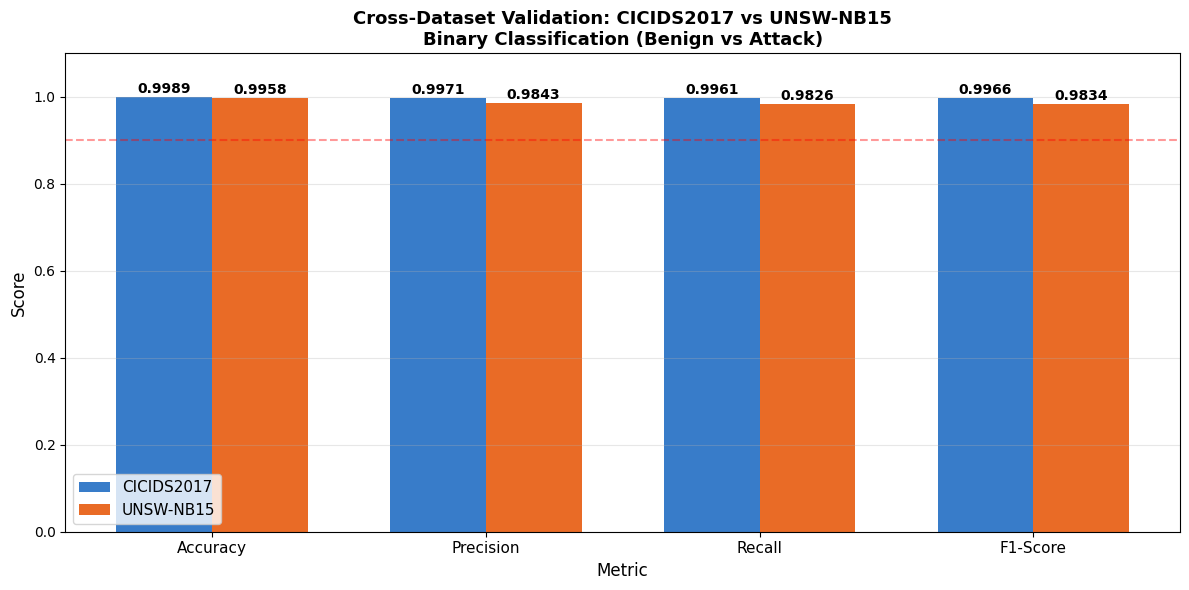


CROSS-DATASET VALIDATION SUMMARY
Metric         CICIDS2017    UNSW-NB15   Difference
-------------------------------------------------------
  Accuracy         0.9989       0.9958    -0.0030 ↓
  Precision        0.9971       0.9843    -0.0128 ↓
  Recall           0.9961       0.9826    -0.0135 ↓
  F1-Score         0.9966       0.9834    -0.0132 ↓

Cross-dataset validation COMPLETE


In [10]:
# Cross-Dataset Comparison Plot 
import matplotlib.pyplot as plt0

# Metrics for both datasets
metrics_cicids = {
    'Accuracy' : accuracy_score(y_test_c, y_pred_c),
    'Precision': precision_score(y_test_c, y_pred_c),
    'Recall'   : recall_score(y_test_c, y_pred_c),
    'F1-Score' : f1_score(y_test_c, y_pred_c)
}
metrics_unsw = {
    'Accuracy' : accuracy_score(y_test_u, y_pred_u),
    'Precision': precision_score(y_test_u, y_pred_u),
    'Recall'   : recall_score(y_test_u, y_pred_u),
    'F1-Score' : f1_score(y_test_u, y_pred_u)
}

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2,
               [metrics_cicids[m] for m in metric_names],
               width, label='CICIDS2017', color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2,
               [metrics_unsw[m] for m in metric_names],
               width, label='UNSW-NB15', color='#E65100', alpha=0.85)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Cross-Dataset Validation: CICIDS2017 vs UNSW-NB15\nBinary Classification (Benign vs Attack)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='0.90 threshold')

for bar in bars1:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}\\cross_dataset_validation.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*55)
print("CROSS-DATASET VALIDATION SUMMARY")
print("="*55)
print(f"{'Metric':<12} {'CICIDS2017':>12} {'UNSW-NB15':>12} {'Difference':>12}")
print("-"*55)
for m in metric_names:
    c = metrics_cicids[m]
    u = metrics_unsw[m]
    diff = u - c
    direction = '↑' if diff > 0 else '↓'
    print(f"  {m:<10} {c:>12.4f} {u:>12.4f} {diff:>+10.4f} {direction}")

print("\n" + "="*55)

print(f"Cross-dataset validation COMPLETE")